# BW \#103 CDC data
On January 20th, Donald Trump returned to the White House for a second presidential term. 

## Data and six questions
The data comes from one of the affected government agencies, to see the depth and breadth of what US government agencies provide : https://data.cdc.gov/NCHS/Provisional-COVID-19-death-counts-and-rates-by-mon/yrur-wghw/about_data. It's a CSV file describing the number of deaths from each of three diseases (covid-19, influenza, and RSV) over the last few years, with week-by-week numbers separated out by ethnic group, age, and sex

## Challenges
The learning goals involve Multi-indexes, Working with dates and times, Pivot tables, plotting, and Window functions.
- Load the CDC's data from a CSV file into a data frame. Keep only the columns 'demographic_type', 'weekending_date', 'pathogen', 'demographic_values', 'deaths', and 'total_deaths'. Create a three-part multi-index with demographic_type, weekending_date, and pathogen. Remove rows in which the value of "pathogen" is "Combined". The "weekending_date" column should be treated as a datetime value.
- Create a bar plot showing, for each quarter, the number of people who died in the US from influenza. Each bar should be subdivided into subplots for age group. Does any part of this data seem unusual? What might explain it?



### Load the CDC's data from a CSV file into a data frame. Keep only the columns 'demographic_type', 'weekending_date', 'pathogen', 'demographic_values', 'deaths', and 'total_deaths'. Create a three-part multi-index with demographic_type, weekending_date, and pathogen. Remove rows in which the value of "pathogen" is "Combined". The "weekending_date" column should be treated as a datetime value.

In [1]:
import pandas as pd
filename = r"C:\Users\npigeon1\Pandas-Bamboo-Weekly-1\BW #103 CDCdata\Provisional_Percent_of_Deaths_for_COVID-19__Influenza__and_RSV_by_Select_Characteristics_20250328.csv"

In [2]:
df = (
    pd
    .read_csv(filename, 
              parse_dates=['weekending_date'],
                usecols=['demographic_type', 'weekending_date', 'pathogen',
                         'demographic_values', 'deaths', 'total_deaths'])
    .loc[lambda df_: df_['pathogen'] != 'Combined']
    .set_index(['demographic_type', 'weekending_date', 'pathogen'])
)
df.shape

(13536, 3)

In [3]:
df.head()

demographic_values  deaths  \
demographic_type weekending_date pathogen                               
Race/Ethnicity   2019-11-02      COVID-19           AI/AN, NH     0.0   
                                 COVID-19           Black, NH     0.0   
                                 COVID-19           White, NH     0.0   
                                 COVID-19  Multiple/Other, NH     0.0   
                                 COVID-19       Not Available     0.0   

                                           total_deaths  
demographic_type weekending_date pathogen                
Race/Ethnicity   2019-11-02      COVID-19           350  
                                 COVID-19          6410  
                                 COVID-19         41574  
                                 COVID-19           224  
                                 COVID-19             0

### Create a bar plot showing, for each quarter (i.e., 3-month period), the number of people who died in the US from influenza. Each bar should be subdivided into subplots for age group. Does any part of this data seem unusual? What might explain it?

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

For starters, we're only interested in those rows where the demographic_type is 'Age Group' and where pathogen is 'Influenza'. Both of those columns are part of our index, but they're in the first and third columns of the index, making it a bit tricky to retrieve matching rows using just .loc.

However, we can use .xs, the "cross-section" method we can use to retrieve selected rows from a multi-index. 

In [4]:
(
    df
    .xs(('Age Group', 'Influenza'), 
        level=['demographic_type', 'pathogen'])
)

,demographic_values,deaths,total_deaths
weekending_date,,,
2023-06-10,65+ years,19.0,41346
2023-06-17,65+ years,22.0,41544
2023-06-24,65+ years,22.0,41231
2023-07-01,65+ years,19.0,40931
2023-07-08,65+ years,21.0,40718
...,...,...,...
2023-05-06,0-17 years,0.0,715
2023-05-13,0-17 years,NaN,710
2023-05-20,0-17 years,0.0,703


From this, I need to create a different data frame, one in which the rows represent each quarter (i.e., 3-month period) and the columns represent the different age groups. To do that, I'll use pivot_table, using weekending_date for the rows and demographic_values for the columns. 

Since we want the number of deaths for each age group at each date, I asked to use deaths as the value column and then sum as an aggregation function – although since there will be only one value for each date/age-group intersection, no need to specify anything.

In [7]:
(
    df
    .xs(('Age Group', 'Influenza'), 
        level=['demographic_type', 'pathogen'])
    .pivot_table(values='deaths', 
               index='weekending_date',
               columns='demographic_values',
               aggfunc='sum')
)

demographic_values,0-17 years,18-64 years,65+ years
weekending_date,,,
2018-01-06,14.0,196.0,833.0
2018-01-13,14.0,289.0,1234.0
2018-01-20,13.0,328.0,1285.0
2018-01-27,17.0,298.0,1135.0
2018-02-03,0.0,265.0,1087.0
...,...,...,...
2025-02-15,24.0,369.0,1298.0
2025-02-22,12.0,327.0,1236.0
2025-03-01,10.0,231.0,991.0


To get only one bar per quarter, use `resample` = a form of grouping that work on time series (=df with `datetime` values in the index). 

Here, we'll invoke resample with an argument of '1QE', meaning that we want to get a result for the end of each quarter, summing all of the values that fell into that quarter:

In [12]:
(
    df
    .xs(('Age Group', 'Influenza'), 
        level=['demographic_type', 'pathogen'])
    .pivot_table(values='deaths', 
               index='weekending_date',
               columns='demographic_values',
               aggfunc='sum')
    .resample('1QE').sum()
)

demographic_values,0-17 years,18-64 years,65+ years
weekending_date,,,
2018-03-31,113.0,2534.0,9977.0
2018-06-30,0.0,185.0,837.0
2018-09-30,0.0,0.0,10.0
2018-12-31,0.0,162.0,316.0
2019-03-31,78.0,1613.0,3424.0
2019-06-30,0.0,287.0,985.0
2019-09-30,0.0,0.0,44.0
2019-12-31,15.0,282.0,476.0
2020-03-31,167.0,2451.0,4272.0


Finally, we can create our bar plot with plot.bar. But rather than have separate bars for each age group, I asked to stack them on top of one another with stacked=True:

<Axes: xlabel='weekending_date'>

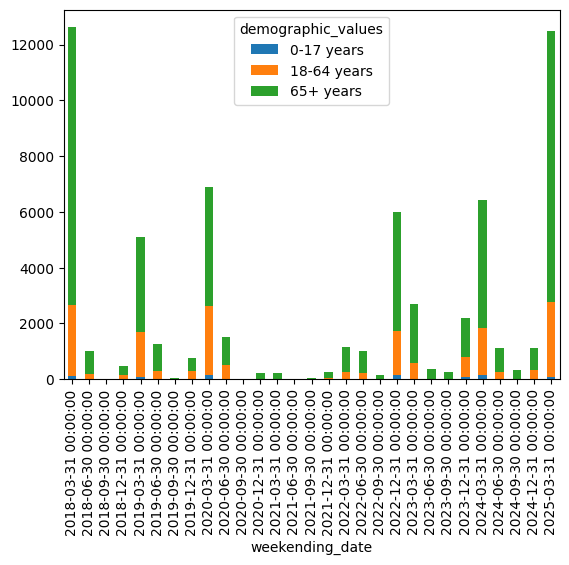

In [13]:
(
    df
    .xs(('Age Group', 'Influenza'), 
        level=['demographic_type', 'pathogen'])
    .pivot_table(values='deaths', 
               index='weekending_date',
               columns='demographic_values',
               aggfunc='sum')
    .resample('1QE').sum()
    .plot.bar(stacked=True)
)

See the huge dip in influenza deaths in the center of the graph? that matches the Covid19 pandemic pretty well; since we were all at home the virus didn't really have anywhere to go and infect others, even during the winter flu season. We can also see the seasonality of flu infections in these graphs too. 

We also see not suprisingly that people 65 and older are the overwhelming buk of flu deaths each year and people 0-17 are a very small proportion. 